# Your Corpus Editions vs Total European Book Production
Compare the number of editions in your corpus with total European book production (1470-1650)

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## 1. Load Your Corpus Data

In [75]:
# Load your book data
books = pd.read_csv('full_book_data_feb_25.csv')

print("Corpus data shape:", books.shape)
print("\nFirst few rows:")
print(books.head())
print("\nColumn names:", books.columns.tolist())

Corpus data shape: (359, 11)

First few rows:
                                                book  \
0  http://sphaera.mpiwg-berlin.mpg.de/id/item/83a...   
1  http://sphaera.mpiwg-berlin.mpg.de/id/item/8a2...   
2  http://sphaera.mpiwg-berlin.mpg.de/id/item/a09...   
3  http://sphaera.mpiwg-berlin.mpg.de/id/item/57c...   
4  http://sphaera.mpiwg-berlin.mpg.de/id/item/55b...   

                                               label   bid  \
0     Opus sphericum magistri Ioannis de Sacro busto  2118   
1  Introductorium compendiosum in Tractatum spere...  1860   
2                         Sphaera Iani de Sacrobusto  1772   
3  Quaestiones novae, in libellum de Sphaera Ioha...  2117   
4                                      Sphaera Mundi  1865   

                                   authors  \
0                  Sacrobosco, Johannes de   
1   John of Glogów;Sacrobosco, Johannes de   
2  Sacrobosco, Johannes de;Apianus, Petrus   
3  Sacrobosco, Johannes de;Beyer, Hartmann   
4             

## 2. Count Editions in Your Corpus

In [76]:
# Count number of images (editions) per year_interval
corpus_editions = books.groupby('year_interval', observed=False).size()

print("Number of editions (images) in your corpus per interval:")
print(corpus_editions)
print(f"\nTotal editions in your corpus: {corpus_editions.sum()}")

Number of editions (images) in your corpus per interval:
year_interval
1470-1489    14
1490-1509    37
1510-1529    30
1530-1549    48
1550-1569    88
1570-1589    69
1590-1609    45
1610-1629    23
1630-1650     4
dtype: int64

Total editions in your corpus: 358


## 3. Load USTC Total European Editions

In [77]:
# Load TOTAL European editions (no places, just overall count)
ustc_europe = pd.read_csv('../ustc_data/ustc_europe_1470_1650.csv')

print("USTC Total European Editions by 20-year Period:")
print(ustc_europe)
print(f"\nTotal editions printed in Europe (1470-1650): {ustc_europe['count'].sum():,.0f}")

USTC Total European Editions by 20-year Period:
      period  from_year  to_year   count
0  1470-1489       1470     1489   14363
1  1490-1509       1490     1509   30122
2  1510-1529       1510     1529   43920
3  1530-1549       1530     1549   54363
4  1550-1569       1550     1569   78343
5  1570-1589       1570     1589   96510
6  1590-1609       1590     1609  132124
7  1610-1629       1610     1629  185177
8  1630-1649       1630     1649  209061

Total editions printed in Europe (1470-1650): 843,983


## 4. Prepare Data for Comparison

In [78]:
# Create aligned data for plotting
x_labels = [str(interval) for interval in corpus_editions.index]
x_positions = range(len(x_labels))

print("Corpus intervals:", x_labels)
print("\nUSTC periods:", ustc_europe['period'].tolist())

Corpus intervals: ['1470-1489', '1490-1509', '1510-1529', '1530-1549', '1550-1569', '1570-1589', '1590-1609', '1610-1629', '1630-1650']

USTC periods: ['1470-1489', '1490-1509', '1510-1529', '1530-1549', '1550-1569', '1570-1589', '1590-1609', '1610-1629', '1630-1649']


## 5. Create Dual-Axis Comparison Plot

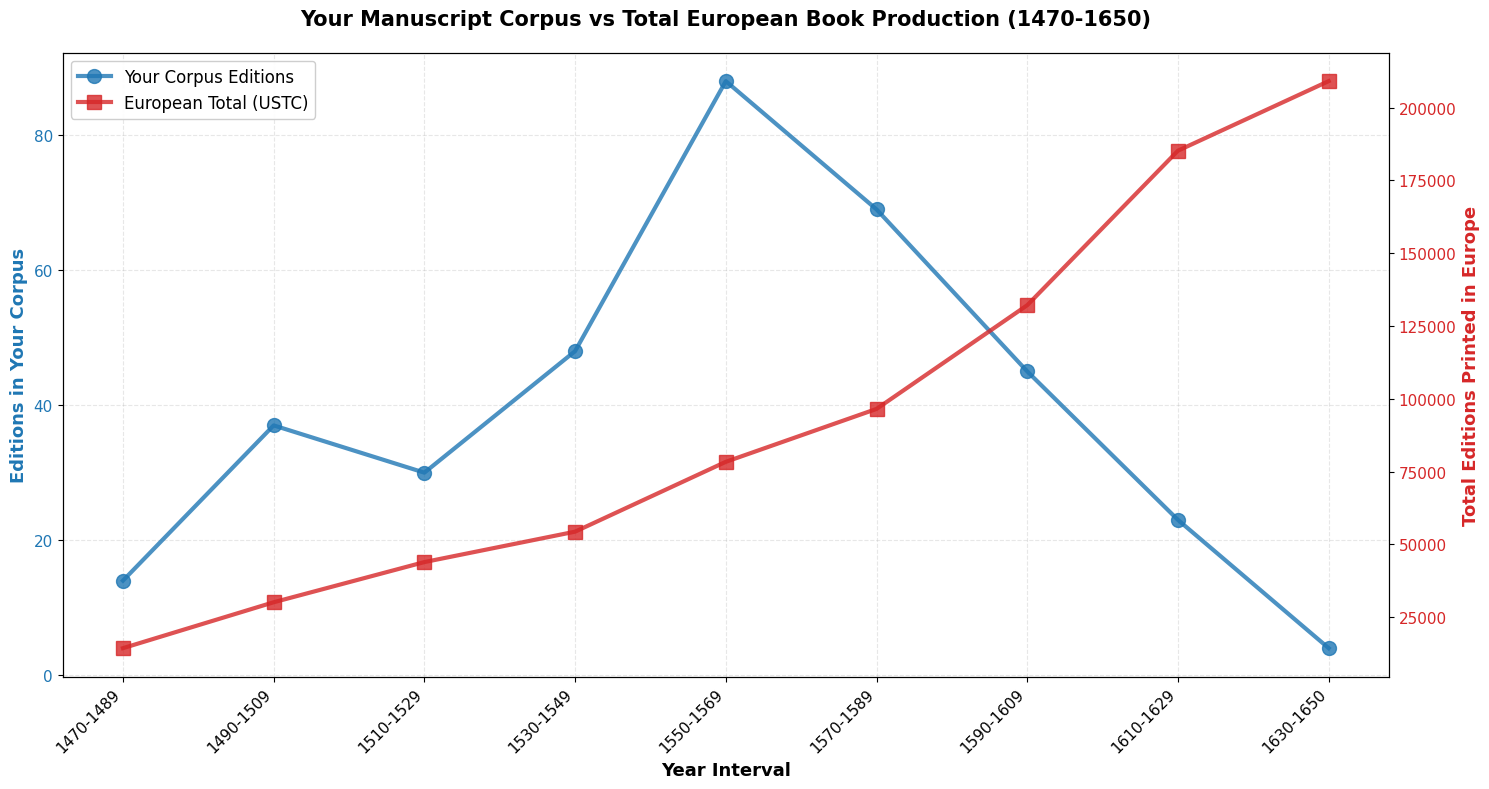

✅ Plot created successfully!


In [80]:
# Create figure with dual y-axes
fig, ax1 = plt.subplots(figsize=(15, 8))

# ===== LEFT Y-AXIS: Your Corpus Editions =====
color_corpus = 'tab:blue'
ax1.set_xlabel('Year Interval', fontsize=13, fontweight='bold')
ax1.set_ylabel('Editions in Your Corpus', color=color_corpus, fontsize=13, fontweight='bold')

line1 = ax1.plot(x_positions, corpus_editions.values, 
                  label='Your Corpus Editions', marker='o', color=color_corpus, 
                  linewidth=3, markersize=10, alpha=0.8)
ax1.tick_params(axis='y', labelcolor=color_corpus, labelsize=11)
ax1.grid(True, alpha=0.3, linestyle='--')

# ===== RIGHT Y-AXIS: USTC Total European Editions =====
ax2 = ax1.twinx()
color_europe = 'tab:red'
ax2.set_ylabel('Total Editions Printed in Europe', color=color_europe, fontsize=13, fontweight='bold')

line2 = ax2.plot(x_positions, ustc_europe['count'].values,
                  label='European Total (USTC)', marker='s', color=color_europe, 
                  linewidth=3, markersize=10, alpha=0.8)
ax2.tick_params(axis='y', labelcolor=color_europe, labelsize=11)

# Set x-axis labels
ax1.set_xticks(x_positions)
ax1.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=11)

# Title and legends
plt.title('Your Manuscript Corpus vs Total European Book Production (1470-1650)', 
          fontsize=15, fontweight='bold', pad=20)

# Combine legends from both axes
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=12, framealpha=0.95)

fig.tight_layout()

plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/context_quantitative_overview/num_books.png', dpi=300)


plt.show()




print("✅ Plot created successfully!")

## 6. Summary Statistics

In [26]:
total_corpus = corpus_editions.sum()
total_europe = ustc_europe['count'].sum()

print("="*70)
print("YOUR CORPUS - EDITION COUNTS (1470-1650)")
print("="*70)
for interval, count in corpus_editions.items():
    print(f"{interval:20} {count:8} editions")
print(f"{'TOTAL':20} {total_corpus:8} editions")

print("\n" + "="*70)
print("TOTAL EUROPEAN PRODUCTION (USTC, 1470-1650)")
print("="*70)
for idx, row in ustc_europe.iterrows():
    print(f"{row['period']:20} {row['count']:12,.0f} editions")
print(f"{'TOTAL':20} {total_europe:12,.0f} editions")

print("\n" + "="*70)
print("COMPARISON")
print("="*70)
print(f"Your corpus total:    {total_corpus:12} editions")
print(f"European total:       {total_europe:12,.0f} editions")
print(f"Ratio:                1 : {total_europe/total_corpus:,.1f}")
print(f"\nYour corpus represents {100*total_corpus/total_europe:.2f}% of European production")

peak_corpus_idx = corpus_editions.idxmax()
peak_europe_idx = ustc_europe['count'].idxmax()

print(f"\n📈 Peak in your corpus: {peak_corpus_idx} ({corpus_editions.max()} editions)")
print(f"📈 Peak in Europe:      {ustc_europe.loc[peak_europe_idx, 'period']} ({ustc_europe.loc[peak_europe_idx, 'count']:,.0f} editions)")

YOUR CORPUS - EDITION COUNTS (1470-1650)
1470-1489                  14 editions
1490-1509                  37 editions
1510-1529                  30 editions
1530-1549                  48 editions
1550-1569                  88 editions
1570-1589                  69 editions
1590-1609                  45 editions
1610-1629                  23 editions
1630-1650                   4 editions
TOTAL                     358 editions

TOTAL EUROPEAN PRODUCTION (USTC, 1470-1650)
1470-1489                  14,363 editions
1490-1509                  30,122 editions
1510-1529                  43,920 editions
1530-1549                  54,363 editions
1550-1569                  78,343 editions
1570-1589                  96,510 editions
1590-1609                 132,124 editions
1610-1629                 185,177 editions
1630-1649                 209,061 editions
TOTAL                     843,983 editions

COMPARISON
Your corpus total:             358 editions
European total:            843,983 edi

## 7. Trend Analysis

In [27]:
print("\n" + "="*70)
print("GROWTH TRENDS")
print("="*70)

# Calculate growth rates
corpus_growth = corpus_editions.pct_change() * 100
europe_growth = ustc_europe['count'].pct_change() * 100

print("\nCorpus growth rate per interval:")
for interval, growth in corpus_growth.items():
    if pd.notna(growth):
        direction = "↑" if growth > 0 else "↓"
        print(f"  {interval}: {direction} {abs(growth):.1f}%")

print("\nEuropean growth rate per period:")
for idx, growth in enumerate(europe_growth):
    if pd.notna(growth) and idx > 0:
        direction = "↑" if growth > 0 else "↓"
        print(f"  Period {idx}: {direction} {abs(growth):.1f}%")


GROWTH TRENDS

Corpus growth rate per interval:
  1490-1509: ↑ 164.3%
  1510-1529: ↓ 18.9%
  1530-1549: ↑ 60.0%
  1550-1569: ↑ 83.3%
  1570-1589: ↓ 21.6%
  1590-1609: ↓ 34.8%
  1610-1629: ↓ 48.9%
  1630-1650: ↓ 82.6%

European growth rate per period:
  Period 1: ↑ 109.7%
  Period 2: ↑ 45.8%
  Period 3: ↑ 23.8%
  Period 4: ↑ 44.1%
  Period 5: ↑ 23.2%
  Period 6: ↑ 36.9%
  Period 7: ↑ 40.2%
  Period 8: ↑ 12.9%


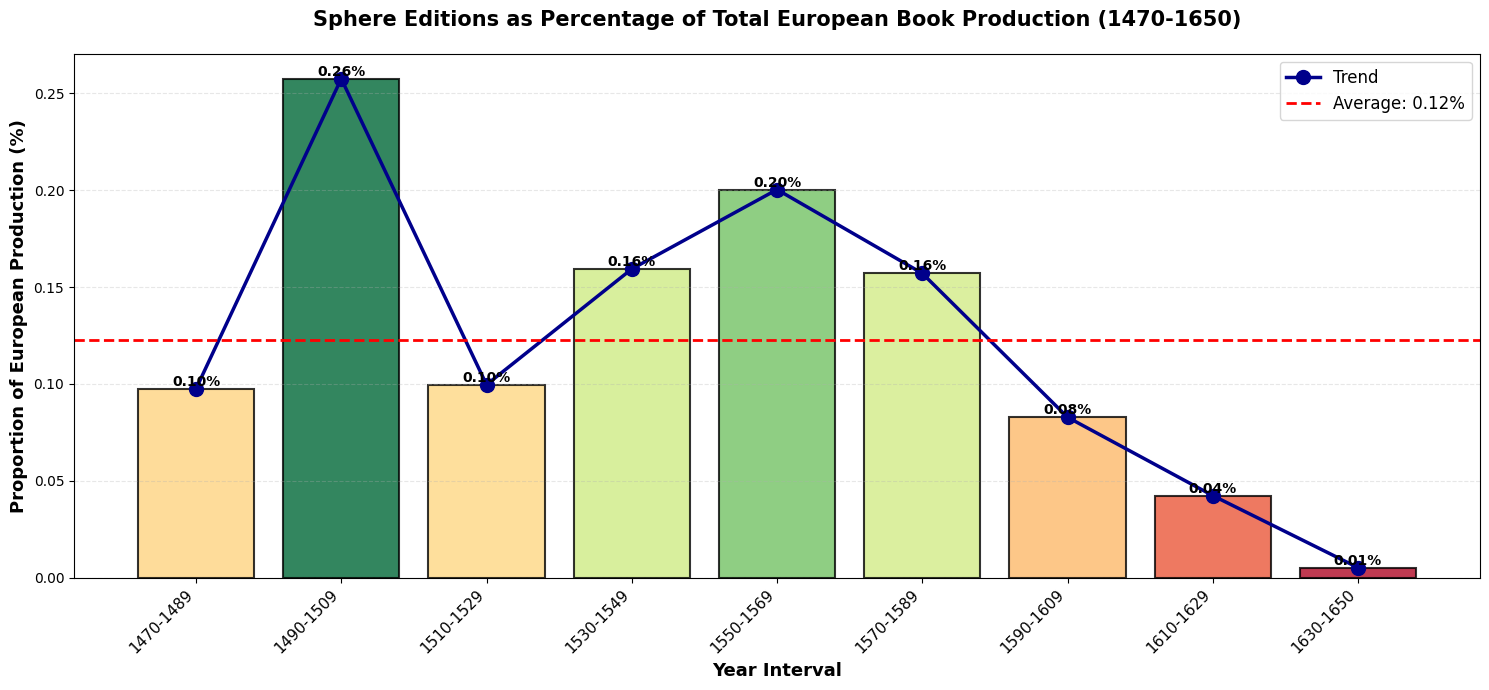

✅ Proportion plot created!


In [81]:
# Calculate proportions first (needed for this visualization)
# Match intervals to periods (your intervals to USTC periods)
proportions = []
intervals_list = list(corpus_editions.index)

for i, interval in enumerate(intervals_list):
    corpus_count = corpus_editions[interval]
    # Find matching USTC period (2 intervals = 1 USTC period)
    ustc_idx = i // 2
    if ustc_idx < len(ustc_europe):
        ustc_count = ustc_europe.iloc[ustc_idx]['count']
        proportion = (corpus_count / ustc_count) * 100
        proportions.append({
            'interval': interval,
            'corpus_editions': corpus_count,
            'europe_total': ustc_count,
            'proportion': proportion
        })

proportions_df = pd.DataFrame(proportions)

# Create proportion plot
fig, ax = plt.subplots(figsize=(15, 7))

# Plot proportions as bar chart
colors = plt.cm.RdYlGn(proportions_df['proportion'] / proportions_df['proportion'].max())
bars = ax.bar(range(len(proportions_df)), proportions_df['proportion'], color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# Add a line to show the trend
ax.plot(range(len(proportions_df)), proportions_df['proportion'], marker='o', color='darkblue', linewidth=2.5, markersize=10, label='Trend')

# Add average line
avg_proportion = proportions_df['proportion'].mean()
ax.axhline(y=avg_proportion, color='red', linestyle='--', linewidth=2, label=f'Average: {avg_proportion:.2f}%')

# Labels and title
ax.set_xlabel('Year Interval', fontsize=13, fontweight='bold')
ax.set_ylabel('Proportion of European Production (%)', fontsize=13, fontweight='bold')
ax.set_title('Sphere Editions as Percentage of Total European Book Production (1470-1650)', fontsize=15, fontweight='bold', pad=20)

# Set x-axis labels
ax.set_xticks(range(len(proportions_df)))
ax.set_xticklabels(proportions_df['interval'].values, rotation=45, ha='right', fontsize=11)

# Grid and legend
ax.grid(True, alpha=0.3, axis='y', linestyle='--')
ax.legend(fontsize=12, loc='best')

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, proportions_df['proportion'])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.2f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

fig.tight_layout()

plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/context_quantitative_overview/relative_part.png', dpi=300)

plt.show()

print("✅ Proportion plot created!")

## 9. Visualize Proportions Over Time

In [29]:
# Calculate proportions
# Match intervals to periods (your intervals to USTC periods)
proportions = []
intervals_list = list(corpus_editions.index)

for i, interval in enumerate(intervals_list):
    corpus_count = corpus_editions[interval]
    # Find matching USTC period (2 intervals = 1 USTC period)
    ustc_idx = i // 2
    if ustc_idx < len(ustc_europe):
        ustc_count = ustc_europe.iloc[ustc_idx]['count']
        proportion = (corpus_count / ustc_count) * 100
        proportions.append({
            'interval': interval,
            'corpus_editions': corpus_count,
            'europe_total': ustc_count,
            'proportion': proportion
        })

proportions_df = pd.DataFrame(proportions)

print("="*80)
print("SPHERE EDITIONS AS % OF TOTAL EUROPEAN PRODUCTION")
print("="*80)
print(f"{'Interval':20} {'Sphere Editions':15} {'Europe Total':15} {'Proportion %':15}")
print("-"*80)
for _, row in proportions_df.iterrows():
    interval_str = str(row['interval'])
    editions = int(row['corpus_editions'])
    europe = int(row['europe_total'])
    prop = float(row['proportion'])
    print(f"{interval_str:20} {editions:15} {europe:15} {prop:14.4f}%")
print("-"*80)
avg_editions = proportions_df['corpus_editions'].mean()
avg_europe = proportions_df['europe_total'].mean()
avg_prop = proportions_df['proportion'].mean()
print(f"{'AVERAGE':20} {avg_editions:15.0f} {avg_europe:15.0f} {avg_prop:14.4f}%")

print(f"\n📊 Your corpus represents {proportions_df['proportion'].mean():.2f}% of European production on average")

SPHERE EDITIONS AS % OF TOTAL EUROPEAN PRODUCTION
Interval             Sphere Editions Europe Total    Proportion %   
--------------------------------------------------------------------------------
1470-1489                         14           14363         0.0975%
1490-1509                         37           14363         0.2576%
1510-1529                         30           30122         0.0996%
1530-1549                         48           30122         0.1594%
1550-1569                         88           43920         0.2004%
1570-1589                         69           43920         0.1571%
1590-1609                         45           54363         0.0828%
1610-1629                         23           54363         0.0423%
1630-1650                          4           78343         0.0051%
--------------------------------------------------------------------------------
AVERAGE                           40           40431         0.1224%

📊 Your corpus represents 0.1

## 8. Calculate Proportions - What % of European Production was Sphere Editions?

## 8. Save the Plot (Optional)